### Test running of slimline code

</b> Author:   </b>  Sam MacKay


Disabling python multi-threading...
Initialising jax...

Default jax backend: cpu
Available devices: [CpuDevice(id=0), CpuDevice(id=1), CpuDevice(id=2), CpuDevice(id=3), CpuDevice(id=4), CpuDevice(id=5), CpuDevice(id=6), CpuDevice(id=7), CpuDevice(id=8), CpuDevice(id=9), CpuDevice(id=10), CpuDevice(id=11), CpuDevice(id=12), CpuDevice(id=13), CpuDevice(id=14), CpuDevice(id=15)]
Predicted size in memory of domain: 8.0 MB

Memory prior to domain creation:
 - total : 14.982192993164062 GB
 - free  : 6.429271697998047 GB
 - used  : 9.503658294677734 GB

Est. domain memory limit: 26.400000000000002 MB
 --> inc. +10.0% variance margin

Coordinates have shape of (128, 128, 128) --> no padding required.

Generating test exponential decay periodic -e field...

Number of domain batches: 1
Number of ray batches: 1

Est. size in memory of rays (1 = 712 B): 135.80322265625 MB
 --> Np = 200000

No need to generate any sections of the domain, batching not utilised.
 --> tracing a depth of 0.01 mm's t

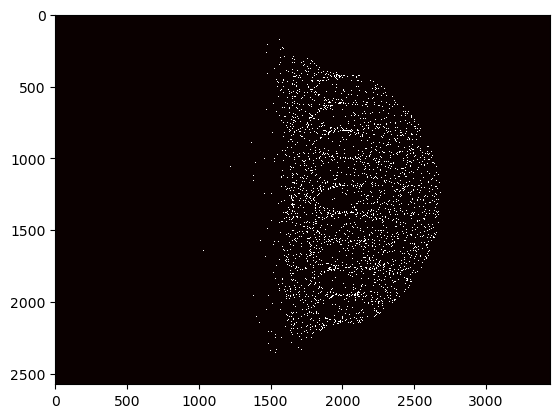

In [1]:
import jax_init

import slimline as solver

import importlib
importlib.reload(solver)

import numpy as np
import matplotlib.pyplot as plt

# define some extent, the domain should be distributed as +extent to -extent, does not need to be cubic
extent_x = 5e-3
extent_y = 5e-3
extent_z = 10e-3

n_cells = 128

probing_extent = extent_z
probing_direction = 'z'

lengths = 2 * np.array([extent_x, extent_y, extent_z])
domain = solver.ScalarDomain(lengths, n_cells, ne_type = "test_exponential_cos", probing_direction = probing_direction)

lwl = 1064e-9 #define laser wavelength

# initialise beam
Np = 200000    # number of photons
divergence = 5e-5   # realistic divergence value
beam_size = extent_x    # beam radius
ne_extent = probing_extent  # so the beam knows where to initialise initial positions
beam_type = 'circular'

beam_definition = solver.Beam(
    Np, beam_size, divergence, ne_extent,
    probing_direction = probing_direction,
    beam_type = "circular"
)

rf, _, duration = solver.solve(beam_definition.s0, domain, probing_extent)

#in the diagnostic initialisation, details on the lens configurations, and detector dimensions can be specified
refractometer = solver.Refractometry(lwl, rf)
# cam't clear_mem if you want to generate other graphs afterwards
refractometer.plot_rays(bin_scale = 1, clear_mem = False)

plt.imshow(refractometer.H, cmap = 'hot', interpolation = 'nearest', clim = (0.5, 1))
plt.show()